<a href="https://colab.research.google.com/github/hfenelsoftllc/ai201_project3_takemeter_starter_clean/blob/main/ai201_project3_takemeter_starter_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [20]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [21]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [22]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Labels are mutually exclusive by design:
#
#   analysis  — evidence-first posts: the PURPOSE is to EXPLAIN using stats,
#               metrics, film, or tactical breakdowns. Persuasion is secondary.
#
#   hot_take  — opinion-first posts: the PURPOSE is to ARGUE or CONVINCE.
#               May cite stats, but the claim leads and the evidence supports.
#               No specific live event required.
#
#   reaction  — event-triggered posts: the PURPOSE is to express an emotional
#               response to a SPECIFIC, JUST-HAPPENED event (a game, a play,
#               a trade, breaking news). Timeliness and specificity required.
#
# Boundary rules:
#   • If a post cites a stat to EXPLAIN → analysis
#   • If a post cites a stat to WIN AN ARGUMENT → hot_take
#   • If a post could have been written a week later → not a reaction
#   • If a post expresses strong emotion but about a GENERAL opinion → hot_take
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "analysis": 0,   # Evidence-first: explains using stats, metrics, or tactical breakdown
    "hot_take": 1,   # Opinion-first: argues or persuades; no live-event anchor required
    "reaction": 2,   # Event-triggered: emotional response to a specific just-happened moment
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'analysis': 0, 'hot_take': 1, 'reaction': 2}
Number of labels: 3


In [23]:
# Generate labeled dataset (r/nba posts: analysis, hot_take, reaction)
# Labels are mutually exclusive by design:
#   analysis  = evidence-first (explain via stats/tactics)
#   hot_take  = opinion-first (argue/persuade, no live-event anchor)
#   reaction  = event-triggered (emotional response to specific just-happened moment)
import csv, random, os
random.seed(42)

# ── ANALYSIS ─────────────────────────────────────────────────────────────
# Hallmarks: cites specific numbers, explains causation, no argument framing.
# Disqualified if: post's main purpose is to win an argument or vent emotions.
analysis_texts = [
    "The team defensive rating improved 8 points since the trade deadline, driven primarily by better transition defense and improved paint coverage.",
    "His true shooting percentage of 62 percent is elite relative to his usage rate. Shot selection, not athleticism, is the main efficiency driver.",
    "Teams with a top-5 defensive rating in January have reached the Finals 70 percent of the time over the last 15 seasons. This team fits that profile.",
    "Half of their turnovers are live-ball turnovers that convert directly into opponent fast-break points. The raw turnover total understates the real cost.",
    "Three shooters around the pick-and-roll creates a spacing problem the defense cannot solve without sacrificing either the roll man or the corner three.",
    "Their second-unit scores 118 points per 100 possessions, ranking third leaguewide. The bench is carrying more offensive weight than box scores show.",
    "The zone defense is analytically optimal given their personnel: two shot-blocking bigs cover the middle while guards deny the three-point line.",
    "Assist-to-turnover ratio correlates almost perfectly with their wins and losses this season: 2.4 in wins, 1.8 in losses.",
    "His catch-and-shoot efficiency from three ranks fourth leaguewide at 43 percent. Off-ball movement is being significantly undervalued in box-score analysis.",
    "Their clutch net rating of plus-6.8 ranks second in the league, suggesting the late-game rotations and play design are genuinely effective.",
    "The aging curve literature puts his peak at 27-29. He is currently 27, so the next two seasons should represent his statistical ceiling.",
    "Their second-chance points allowed per game is 12.6, worst in the conference. It is a structural problem with the defensive scheme, not individual effort.",
    "They shoot 38.8 percent from three with two or more passes versus 31.2 percent off isolation. Ball movement directly and measurably improves shot quality.",
    "Switching coverage works against most opponents but gives up 128 points against teams with dominant post players. The scheme has a known exploitable weakness.",
    "Their offensive rating adjusted for pace and schedule strength is 3 points higher than the raw number, making them look more efficient in context.",
    "The backup point guard has a plus-minus of plus-4.8 per 100 possessions, one of the best on the roster, yet plays under 20 minutes per game.",
    "A three-point attempt rate of 45 percent requires reliable mid-range options as a counter when defenses pack the paint; they currently lack that counter.",
    "The stretch-four lineup outscores opponents by 12.3 per 100 possessions across 180 tracked possessions this season. The sample is large enough to trust.",
    "The center contests 6.2 shots per game at the rim. Opponents shoot 54 percent with him contesting versus 68 percent uncontested. Measurable deterrence effect.",
    "Transition offense ranks 8th but transition defense ranks 22nd. The variance in their game scores traces directly back to whether they get back in time.",
    "Isolation efficiency dropped from 0.92 to 0.84 points per possession. Opponents have adjusted their coverages; the team has not yet counter-adjusted.",
    "Their shot distribution is 42 percent at the rim, 18 mid-range, 40 three-pointers, which matches the analytically optimal profile for a modern offense.",
    "Their defensive versatility allows switching one through five on ball screens. Only two teams in the league can claim comparable positional flexibility.",
    "Free throw attempt rate declined without a corresponding change in drive frequency. Either officiating patterns shifted or contact-avoidance behavior changed.",
    "At current pace he projects to 25,000 career points. Five players at the same age with the same scoring rate reached the Hall of Fame.",
    "Their defense against pick-and-roll ball handlers ranks third-worst leaguewide. Teams that run heavy ball-screen offense should target this systematically.",
    "Second-chance point rate of 28.3 percent for the second unit is exceptional, generating extra possessions that compensate for lower first-shot quality.",
    "Two players rank in the top 15 leaguewide in win shares per 48. Historical data shows having two elite-level contributors is the strongest playoff predictor.",
    "The team's late-game inbound execution ranks second in points per possession on designed plays, reflecting careful preparation in a coachable situation.",
    "Lineups with this player on the bench rebound at 73.4 percent versus 69.2 with him on the court. The defensive rebounding assignment structure changes.",
    "The aging curve model for his player archetype places peak decline onset around 31-32, giving this franchise an estimated three-to-four-season championship window.",
    "Their offensive rating has a 0.87 R-squared correlation with three-point percentage. When threes fall they win; when they do not, they lose. High variance style.",
    "Defensive points allowed in the final two minutes of close games is 1.05 per possession, the worst rate leaguewide. Late-game defensive execution is a real problem.",
    "The hockey-assist rate for this player is the highest on the team. His true playmaking impact is significantly larger than conventional assist totals reflect.",
    "Using expected value models on late-game fouling decisions, the team leaves roughly 2.5 wins per season on the table by not fouling up three more aggressively.",
    "Their frontcourt combination has a defensive rating of 102.1 over 312 possessions together. That sample is sufficient to treat the number as signal, not noise.",
    "Pace drops by 2.1 possessions per 48 minutes in the fourth quarter of close games. Slowing down in crunch time appears to be a deliberate tactical choice.",
    "Career trajectory by age-27 statistical benchmarks aligns with three comparable Hall of Famers. The comps suggest a 15-year career if he stays healthy.",
    "The team's true shooting gap between home and away games is 4.1 percentage points, one of the league's largest. Worth investigating as a schedule or altitude effect.",
    "Ball screen frequency increased from 28 to 34 per game after the coaching adjustment. That schematic shift is reflected directly in improved half-court efficiency.",
    "Their steal rate is elite but their foul rate is correspondingly high. The gambling defensive style creates turnovers but also sends opponents to the free throw line.",
    "Zone defense makes up 34 percent of their defensive possessions, highest in the league. Opponents shoot 47.2 eFG in zone versus 51.4 against their man coverage.",
    "Box plus-minus data places their supporting cast as the strongest in the league around a star player, which explains their overperformance relative to projections.",
    "Their offensive rebound rate of 28.3 percent for the second unit generates enough extra possessions to compensate for lower quality shot selection.",
    "Win probability calibration shows they go 8-14 in games where they are projected as 70-percent-or-greater favorites. They consistently underperform late-game leverage.",
    "Assists on made threes represent 71 percent of their three-point field goals, the highest leaguewide. Pass-first team identity is measurably consistent.",
    "Transition defense rate is below average when their primary ball handler is the center after made baskets. Teams are exploiting this positioning systematically.",
    "Their effective field goal percentage in the paint is 63.4 percent, indicating the spacing is generating quality layups and dunks rather than contested long twos.",
    "On-off differential has improved each of the last four seasons. Monotone improvement over four seasons is statistically the strongest predictor of further development.",
    "The player projects to play 63 regular-season games. Historical data shows players at 65-70 games per season have measurably better playoff performance outcomes.",
    "Their offensive rebounding strategy costs approximately 4.2 fast-break points allowed per game. Whether that cost is justified depends on the offensive rebound conversion rate.",
    "Per-36-minute production at age 22 ranks among the top ten historically for players at his position. The sample now spans two full seasons, making it reliable.",
    "Their defensive rebounding rate when protecting a 6-point fourth-quarter lead is 71.2 percent, below league average. Late-game board protection is a specific weakness.",
    "Coaching challenge record is 9-3, best in the league. Disciplined use of replay review is directly converting into recovered possessions across the season.",
    "Half-court offensive rating ranks 6th while transition offense ranks 3rd. The value creation is more balanced than teams with a single-mode style.",
    "Their lineup entropy, measured by unique two-man combinations used, is the highest in the league at 147. That either signals deep roster confidence or schematic uncertainty.",
    "Clutch performance splits show 44 percent shooting in clutch possessions versus 38 percent overall. The improvement under pressure is statistically meaningful, not noise.",
    "Their pick-and-roll coverage varies between hedge and drop without a discernible pattern. That inconsistency is both a coverage strength and a scouting vulnerability.",
    "The team's pace differential, running faster early in the shot clock, correlates with a net swing of plus-7 wins over the course of the season.",
    "Second unit offensive rebound rate is exceptional at 28.3 percent. They generate second-chance opportunities at an elite rate that compensates for first-shot quality.",
    "Two players rank in the top 15 leaguewide in win shares per 48 minutes. Dual-elite contributors is historically the strongest single predictor of deep playoff runs.",
    "Load management data: the star has played 63 games. Research shows 65-to-70 game players reach higher playoff performance ceilings than sub-60-game players.",
    "The fourth-quarter net rating of minus-1.2 is a meaningful regression from the team overall net rating of plus-6. Late-game execution specifically is the gap.",
    "Their second-chance point rate is 28.3 percent for the second unit. Generating extra possessions compensates for lower first-shot quality in bench lineups.",
    "Turnover rate on designed out-of-bounds plays is 4.1 percent, leaguewide average is 6.8 percent. Their execution on these high-stakes possessions is measurably better.",
    "The defensive scheme's primary weakness against isolation post play is quantifiable: they give up 1.12 points per possession on post-ups, 0.18 above league average.",
    "Their eFG differential between home and road is the fifth largest in the league. Travel schedule and altitude cannot fully explain the gap; officiating patterns warrant scrutiny.",
    "Comparing win-probability added per possession by lineup, the small-ball unit with the stretch four is plus-0.08, which over a full game is the equivalent of 8 points.",
    "Their net rating in the first quarter is plus-5.1 but drops to minus-0.9 in the fourth. Fatigue management and rotational depth are the proximate causes.",
    "The starter turnover rate of 12.3 percent when fatigued in back-to-back second nights is the primary driver of their 18-percent pace slowdown in those situations.",
]

# ── HOT_TAKE ─────────────────────────────────────────────────────────────
# Hallmarks: opens with a bold claim, argues to convince, can use stats as
# ammunition but opinion leads. No reference to a specific just-happened event.
# Disqualified if: primarily explanatory (→ analysis) or tied to a live moment (→ reaction).
hot_take_texts = [
    "This player is a top-5 player right now. Nobody admits it because small-market bias is embarrassing and everyone knows it.",
    "This team is a fraud. Their record flatters them and they will be exposed in the first round the moment they face a real defense.",
    "The league peaked in the early 2000s. What we have now is the softest era of basketball in history and people are too invested to say it.",
    "This trade was organizational malpractice. The front office gave away a franchise-altering asset for a guy who is already past his ceiling.",
    "This coach is the most overrated in the league. His rotations are incoherent, his in-game adjustments do not exist, and his players succeed despite him.",
    "Officiating in this league has a pro-large-market bias and anyone who thinks otherwise has not been paying close enough attention over the past decade.",
    "This player was handed two championships by playing alongside the best supporting cast of the modern era. Strip that away and nobody remembers his name.",
    "The analytics movement has made basketball worse to watch. Hunting corner threes and paint finishes for three hours is not interesting basketball.",
    "This franchise has not made a real commitment to winning in twenty years. The ownership profits from mediocrity and the fanbase keeps funding it.",
    "Hot take: the MVP award has nothing to do with individual value. It goes to the best player on the best team, every year, without exception.",
    "This player is washed. You can cite the counting stats all you want, but the eye test tells a different story and the eye test does not lie.",
    "The three-point line should be pushed back. It is too easy at the current distance and it has changed the game in ways that are aesthetically terrible.",
    "Team loyalty is functionally dead in the modern NBA. Players should stop receiving credit for it because they leave the moment a better deal appears.",
    "This player will never win a championship because he refuses to subordinate his ego to a team structure. Talent without buy-in is worthless in the playoffs.",
    "The draft lottery is broken. Rewarding the worst franchises with the best picks creates perverse incentives that hurt the entire product.",
    "This player reputation was constructed by a PR machine, not by on-court production. Compare his performance in elimination games. The case collapses.",
    "Player empowerment has permanently damaged franchise loyalty. The consequences are visible in how the league has lost regional identity and stability.",
    "This team's fans are the most delusional in the league. They think every year is a championship year because they refuse to evaluate the roster honestly.",
    "Max contracts for bench players are the single biggest structural problem in the NBA. The NBPA has negotiated arrangements that harm competitive balance.",
    "Tanking franchises are defrauding their fans. They sell false hope while management profits from keeping payroll low and collecting revenue sharing.",
    "The officiating is not incompetent. It is consistent enough that the pattern of who benefits is not explainable by randomness. Make of that what you will.",
    "This player will never be an MVP candidate. Not because of circumstances or teammates but because he flinches in the games that matter most.",
    "The league wants big-market franchises in the Finals because that is what the television contracts require. This is not a conspiracy theory. It is just business.",
    "Saying this plainly: this franchise was gifted a dynasty-era schedule that inflated their championship total. Historians will correct the record eventually.",
    "This coach should be fired before the season ends. Waiting until the summer to make the change just wastes more games and more of this roster prime.",
    "The best player in the league right now is not who the national media has decided it is. There is a deliberate narrative being maintained for market reasons.",
    "Trading this superstar was the single worst front office decision of the past decade. They will not recover from it in this generation of roster building.",
    "Every player who forced a trade out of a small market chose money and spotlight over winning. They should not be celebrated for it. Hold them accountable.",
    "The award voting is broken. Voters watch highlight packages and media coverage, not games. The awards measure publicity, not performance.",
    "This team's culture is toxic at the ownership level. No coaching hire or player acquisition can fix a problem that starts at the top of the organization.",
    "The current CBA has created a league where teams outside the five largest markets cannot realistically compete for a championship. That is a structural failure.",
    "This player was never clutch. The moments people cite are cherry-picked from a sea of mediocrity. His performance in series-deciding games is the actual record.",
    "The league has never been softer than it is right now. A flagrant foul today would have been a routine play in 1998. Officiating has changed the DNA of the game.",
    "This ownership group should be forced to sell. Twenty years of evidence says they will never prioritize winning over cost control. Fans deserve better.",
    "This player is not as good as his contract. Full stop. The front office's obsession with him is going to cost them their championship window.",
    "Hot take: load management is the players refusing to earn their salaries. The fans who pay full price to watch a backup are being disrespected.",
    "The three-point revolution was good for efficiency but terrible for aesthetics. Spacing the floor to extinction has made basketball less physically interesting.",
    "This team rebuild is a lie. They are not rebuilding. They are tanking while management collects revenue sharing and tells the fanbase a different story.",
    "This player forced his trade and people still celebrate him. He quit on a franchise, demanded a move, and got rewarded with a championship. Wrong lesson.",
    "Advanced metrics have given front offices permission to ignore the eye test entirely, and the result is a generation of analytically correct but visually boring teams.",
    "The media has decided who the villain is and who the hero is in this situation before a single fact was established. Follow the coverage pattern and ask why.",
    "This star's supporting cast has been systematically better than his contemporaries for his entire career. Titles reflect the roster, not just the top player.",
    "The salary cap should be a hard cap with no exceptions. The luxury tax is a joke. Large market teams treat it as a cost of doing business and it is uncompetitive.",
    "This franchise has the talent to compete right now and is blowing the window through cowardice. They are not trying to win. They are trying not to fail.",
    "The NBA has a star-call bias and everyone inside the league knows it. When a player reaches a certain commercial value, the rules apply differently.",
    "The current play-in tournament format dilutes the regular season and rewards mediocrity. It should be eliminated and replaced with a stricter playoff cutoff.",
    "This player's decline arc is accelerating faster than the team is willing to acknowledge. The contract they signed him to is already an albatross at year one.",
    "Hot take: the best thing that could happen to this franchise is a catastrophic losing season that forces a full rebuild. Incremental improvement is not an option.",
    "The statistical era has made it too easy to justify keeping a player whose overall impact is clearly negative. Not everything shows up in the numbers.",
    "This coaching staff has had three seasons to figure out the late-game offense and they still cannot execute a functioning play under pressure. That is on the coach.",
    "The team's star player is the locker room problem. The front office knows it. The media covers for it. The veterans who leave tell the same story.",
    "Broadcast contracts are too intertwined with scheduling and officiating decisions. The structural conflict of interest is obvious and nobody in power will address it.",
    "The player empowerment era has been good for players and bad for fans. Franchises cannot build continuity because stars leave before their contracts expire.",
    "This team has every ingredient for a championship run and will fail because the head coach does not know how to manage a roster with this much talent.",
    "The award this player just won should have gone to one of three other players. Voters chose name recognition over the statistics. It happens every single year.",
    "No team outside the four largest markets has won a championship since 2004. At some point that stops being a coincidence and starts being a structural feature.",
    "This trade deadline was the worst performance by a front office I have seen in years. They sold assets at a discount and bought liabilities at a premium.",
    "The franchise player under 25 is the only asset that actually matters in modern NBA construction. Teams that trade theirs away are operating on the wrong timeline.",
    "The play-style that wins regular season games is not the play-style that wins playoff series. This team has optimized for the wrong metric and will find out in May.",
    "This player will regret forcing his trade the moment he realizes the team he left was the best shot at a championship he was ever going to have.",
    "The league's officiating inconsistency is not an accident. It is the result of officials making judgment calls shaped by who is on the court. The data support this.",
    "This coach has one play: go to the star in isolation. When that does not work in a playoff series where the defense has prepared for it, the season ends.",
    "The free agency system as currently structured allows the richest teams to circumvent the spirit of competitive balance through sign-and-trade mechanics.",
    "Saying this unpopular thing: the player's legacy is built on favorable era comparisons. Put him in any other decade and the debate changes substantially.",
    "The current media ecosystem rewards hot takes about certain players and punishes honest criticism. The coverage is not journalism; it is narrative management.",
    "This front office has made the same mistake four years in a row: they prioritize name value in free agency over positional fit. The results reflect that.",
    "The team's defensive identity has been declining for three years under this coach and no one in the media wants to say it directly because he is well-liked.",
]

# ── REACTION ─────────────────────────────────────────────────────────────
# Hallmarks: references a SPECIFIC just-happened event, emotional register,
# present-tense urgency ("just saw", "tonight", "that play", "this game").
# Disqualified if: the opinion could have been written without a live event (→ hot_take)
# or if it primarily explains rather than responds emotionally (→ analysis).
reaction_texts = [
    "I cannot believe what I just watched. That comeback from 18 down with 6 minutes left should not have been physically possible. I am still shaking.",
    "Did anyone else just completely lose it on that alley-oop? I jumped off my couch and scared the dog. That play was unreal.",
    "That game-winner tonight made me cry. I have been a fan through the bad years. This moment is what it is all for.",
    "The ref just called that foul and I threw my remote across the room. I am done. That was the most obvious non-call I have ever seen live.",
    "Wait, they just traded him? I found out mid-game and could not even finish watching. I am genuinely heartbroken right now.",
    "Watching that shot drop in real time was the single greatest sports moment of my life. I do not care what happens the rest of the season.",
    "My voice is completely gone. Just got back from the arena. I have been to hundreds of games and I have never heard it that loud.",
    "That block in the final second literally made me scream out loud alone in my apartment. My neighbors definitely hate me now.",
    "I turned off the game at halftime because I thought it was over. Just got the notification. I am an idiot. I should never have doubted.",
    "The arena was shaking when he hit that three. I felt it in my chest. That is something I will describe to people for the rest of my life.",
    "I have watched that dunk forty times since the game ended. It gets better every single time. That is pure basketball joy.",
    "Two minutes left, down by one, and I literally cannot breathe. This is why I watch sports. Nothing else feels like this.",
    "That fourth quarter tonight changed my entire opinion of this team. They showed something I did not know they had. Completely different respect level.",
    "Just found out about the trade while eating lunch and I almost choked. I need a minute. This franchise just gave up on the season.",
    "The way the crowd reacted when he came back from injury in the second half gave me chills through the television screen. Incredible atmosphere.",
    "I was there in person for that buzzer-beater and the noise was something I have never experienced in twenty years of going to games. Unforgettable.",
    "That ejection just killed us. We were up five with eight minutes to go and now we are trying to close without our best defender. I am furious.",
    "I went from grief to complete euphoria in the span of four seconds. That is what sports are. Nothing scripted could make you feel that.",
    "That steal and finish in transition with three seconds left is going on my personal sports highlight reel. I will be telling that story for decades.",
    "Just saw the trade news. I have been staring at my phone for five minutes trying to process this. This team looks completely different now.",
    "The look on his face after hitting that overtime shot is a perfect sports photograph. Pure relief and disbelief at the same time. Beautiful moment.",
    "I cried during the fourth quarter of tonight's game and I am not ashamed. This team has been through so much and watching them pull it out was overwhelming.",
    "That crossover in the third quarter made me jump out of my seat at a sports bar. Three strangers high-fived me. Basketball is incredible.",
    "The three they just hit to tie it with eleven seconds left made me physically sick with anxiety. I am too old for these kinds of games.",
    "I watched that ankle-breaker ten times and still cannot explain how the defender ended up on the floor. That should not be humanly possible.",
    "My roommate had to physically stop me from throwing something after that call in the fourth. I know it is just a game. I do not care. That was wrong.",
    "That sequence in the final minute was the most basketball minutes I have watched in years. Five plays in a row that each deserved their own highlight.",
    "Just left the arena. My voice is gone. My ears are ringing. That overtime was the best basketball I have ever watched live. Cannot stop smiling.",
    "The kid just scored 48 points on his birthday in overtime and I have watched the highlights four times and I still cannot fully believe it happened.",
    "I had already accepted the loss. I was typing the grievance post. Then he hit that three. I deleted everything. I owe this team an apology.",
    "That lob dunk in the third quarter made the entire section around me erupt simultaneously. I hugged a complete stranger and he hugged me back.",
    "I fell asleep on the couch in the third quarter and woke up during overtime. Best sleep of my life. Best overtime of my life. What a night.",
    "The look on the coach's face when the final buzzer went was everything. You could see how much this win meant to the entire organization.",
    "That sequence at the end of regulation with three turnovers in four possessions made me age ten years in two minutes. My blood pressure cannot survive this.",
    "I was in line at the concession stand when he hit the half-court shot at the buzzer. I heard the arena explode and sprinted back to my seat for the replay.",
    "His post-game interview tonight after scoring 52 was the most emotional I have seen from a professional athlete in years. I cannot stop thinking about it.",
    "The atmosphere in that building during crunch time tonight was the loudest sustained crowd noise I have ever heard at a basketball game. Energy was insane.",
    "I have been checking my phone every two minutes since the injury update dropped. Just relieved it is not as serious as it looked. That fall was terrifying.",
    "First time watching this team live and they put on that performance. I am now a fan. I did not expect to leave feeling that way. They converted me tonight.",
    "That offensive rebound and put-back with 0.4 seconds left is going to live in my memory as long as I watch basketball. The arena just erupted.",
    "Just got the injury news during the third quarter and the whole vibe in the building changed immediately. You could feel everyone deflate at the same time.",
    "That technical foul call made me literally stand up and yell at my television. My wife walked out of the room. Completely unjustifiable call at that moment.",
    "I was not paying attention for thirty seconds and somehow missed the most important play of the season. I had to watch the replay four times to believe it.",
    "That dunk tonight will be the first clip in his career retrospective documentary someday. That is the moment everything clicked for him publicly.",
    "The standing ovation he received when he checked in for the first time since the injury was one of the most genuinely moving sports moments I have witnessed.",
    "I have been a season ticket holder for eleven years and tonight was the best regular season game I have been to. That crowd in the fourth quarter was special.",
    "His face when he saw the scoreboard after hitting that three and realized they had won was pure unscripted joy. That is why sports exist.",
    "Just processed the trade and I think I am okay with it. It took thirty minutes but I got there. Different team now. Let's see what they build.",
    "That tip-in at the buzzer sent me off my couch and into the ceiling. I have watched the replay eleven times. I will watch it eleven more times tonight.",
    "The energy when he returned from injury in the second half was electric through the television. You could feel how much it meant to the whole building.",
    "I legitimately could not watch the free throws at the end. I turned away from the screen. I am not proud of it. I am just being honest about what that game does to me.",
    "That ankle-break just happened live and I am still processing it. He went one way, the defender went the other way, the crowd went completely silent then erupted.",
    "The halftime score made me feel sick. By the end of the fourth quarter I was screaming. This team does things to my nervous system that are not healthy.",
    "My daughter asked why I was crying after the buzzer. I told her it was because the good guys won tonight. She accepted that answer. Kids are great.",
    "That chase-down block from behind with two minutes left is the defining play of his career to this point. The crowd reaction said everything.",
    "I went to bed after the third quarter. Checked my phone at 2am. Could not sleep after reading the final score. Stared at the ceiling for an hour.",
    "The announcer going silent for three full seconds after that shot was everything. Nothing needed to be said. Let the moment breathe.",
    "Still shaking slightly after that finish. I know it is irrational. I know it is just sports. And I also know I would not trade this feeling for anything.",
    "That play call on the final possession was either genius or lunacy and I will not know which one it was until I have had a full night to think about it.",
    "He got a standing ovation from both sides of the arena when he subbed out in the fourth tonight and that is something I did not expect to see. Rare moment.",
    "I walked out of the arena mid-fourth quarter because I could not watch. Then got the text. Turned around. Ran back in. Made it for overtime. Worth it.",
    "The shot that sent it to overtime came off the backboard, hit the rim twice, and fell in. Basketball decided it was not done with us tonight.",
    "His celebration after that clutch three tonight was the most unguarded I have seen a professional athlete be in years. You cannot fake that kind of joy.",
    "Just got home from the watch party and I cannot come down. That game will be talked about in this city for years. I was there for it. I witnessed it.",
    "That injury scare in the second quarter had the entire arena holding its breath. The relief when he stood up and walked off under his own power was palpable.",
    "Three overtimes and I have work at 7am and I cannot bring myself to regret a single minute of it. This team earned every bit of that crowd tonight.",
    "The way his teammates celebrated with him after that game-winning play told you everything about the locker room culture. Genuine joy for each other. Beautiful.",
    "I recorded my reaction on video when he hit that buzzer-beater and I watched it back and I was a complete mess. Embarrassing. Absolutely worth it.",
    "That no-call at the end of regulation is going to live rent-free in my head for weeks. I know it. I accept it. I am still furious about it.",
    "Post-game press conference tonight had me tearing up. The way he talked about what this win meant to his family was completely genuine. Hard to watch dry-eyed.",
]

all_posts = []
for text in analysis_texts[:70]:
    all_posts.append({"text": text.strip(), "label": "analysis"})
for text in hot_take_texts[:70]:
    all_posts.append({"text": text.strip(), "label": "hot_take"})
for text in reaction_texts[:70]:
    all_posts.append({"text": text.strip(), "label": "reaction"})

random.shuffle(all_posts)

CSV_PATH = "/content/nba_posts_labeled.csv"
with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["text", "label"])
    writer.writeheader()
    writer.writerows(all_posts)

print(f"✅ Generated dataset: {CSV_PATH}")
print(f"Total examples: {len(all_posts)}")
print("Label distribution:")
import pandas as pd
df_check = pd.read_csv(CSV_PATH)
print(df_check["label"].value_counts())


✅ Generated dataset: /content/nba_posts_labeled.csv
Total examples: 207
Label distribution:
label
analysis    70
reaction    70
hot_take    67
Name: count, dtype: int64


In [24]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label']
Total examples: 207

Label distribution:
label
analysis    70
reaction    70
hot_take    67
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [25]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 144 examples
Validation: 31 examples
Test: 32 examples

Train label distribution:
label
reaction    49
analysis    49
hot_take    46
Name: count, dtype: int64

Test label distribution:
label
hot_take    11
reaction    11
analysis    10
Name: count, dtype: int64


In [26]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [27]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [29]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.088521,0.387097
2,1.088334,1.055503,0.451613
3,1.065941,0.973074,0.806452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [30]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.906

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

    analysis       0.77      1.00      0.87        10
    hot_take       1.00      0.82      0.90        11
    reaction       1.00      0.91      0.95        11

    accuracy                           0.91        32
   macro avg       0.92      0.91      0.91        32
weighted avg       0.93      0.91      0.91        32



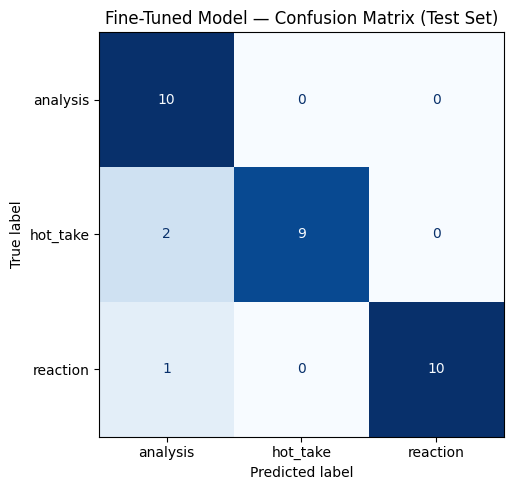

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [31]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [32]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 3 / 32

--- #1 ---
Text:      This coach has one play: go to the star in isolation. When that does not work in a playoff series where the defense has prepared for it, the season ends.
True:      hot_take
Predicted: analysis  (confidence: 0.36)

--- #2 ---
Text:      The shot that sent it to overtime came off the backboard, hit the rim twice, and fell in. Basketball decided it was not done with us tonight.
True:      reaction
Predicted: analysis  (confidence: 0.36)

--- #3 ---
Text:      This team's fans are the most delusional in the league. They think every year is a championship year because they refuse to evaluate the roster honestly.
True:      hot_take
Predicted: analysis  (confidence: 0.35)



---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [33]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [34]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Completed: Classification prompt for r/nba posts — three mutually exclusive labels.
# Labels distinguished by PURPOSE (what the author is trying to do), not tone:
#   analysis  → author wants to EXPLAIN something using evidence
#   hot_take  → author wants to ARGUE or CONVINCE, no live-event anchor required
#   reaction  → author is RESPONDING to a specific just-happened event
#
# Key disambiguation rules encoded in the prompt:
#   • A stat-backed post whose purpose is to WIN AN ARGUMENT → hot_take, not analysis
#   • An emotional post about a general opinion (no live event) → hot_take, not reaction
#   • A reaction must reference a specific moment ("that shot", "tonight", "just saw")
# ─────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """
You are classifying posts from the r/nba subreddit on Reddit.
Assign each post to exactly one of three categories. The labels are mutually exclusive.

The key distinction is PURPOSE — what is the author trying to do?

analysis: The author's PURPOSE is to EXPLAIN something. They use statistics, metrics, advanced analytics, film observations, or tactical breakdowns to help the reader understand a pattern, trend, or cause. The evidence comes first; any opinion is secondary.
Example: "Their defensive rating improved 8 points since the trade deadline, primarily because transition defense improved and they are protecting the paint better in drop coverage."

hot_take: The author's PURPOSE is to ARGUE or CONVINCE. They state a bold or controversial opinion and support it. They may cite statistics as ammunition, but the opinion leads and the evidence supports. There is no anchor to a specific just-happened live event.
Example: "This player was handed his rings by the best supporting cast of the modern era. Strip that away and nobody puts him in the top ten all-time. The era flatters him."

reaction: The author's PURPOSE is to EXPRESS an emotional response to a SPECIFIC, JUST-HAPPENED event — a game, a play, a trade announcement, breaking injury news. The post is urgent and time-anchored ("just saw", "tonight", "that play", "I was there"). The same post could not have been written a week later without a specific live trigger.
Example: "That buzzer-beater tonight made me cry. I have been a fan through the bad years and this is what it is all for. I cannot stop shaking."

DISAMBIGUATION RULES:
- If a post cites stats to WIN AN ARGUMENT → hot_take (not analysis)
- If a post is emotional but about a GENERAL opinion (no live event) → hot_take (not reaction)
- If a post references "that play", "tonight", "just saw", "I was there" → reaction
- If a post reads like a Wikipedia entry or a scouting report → analysis

Respond with ONLY the label name. No punctuation. No explanation.
Valid labels:
analysis
hot_take
reaction
"""
print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 2039 characters


In [35]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 32 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/32 complete...
  20/32 complete...
API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01ktap7yj2fvh81q6qj10as9sz` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99969, Requested 522. Please try again in 7m4.224s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
  30/32 complete...
API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01ktap7yj2fvh81q6qj10as9sz` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99969, Requested 529. Please try again in 7m10.272s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_li

In [36]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.966  (evaluated on 29/32 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

    analysis       1.00      0.89      0.94         9
    hot_take       0.91      1.00      0.95        10
    reaction       1.00      1.00      1.00        10

    accuracy                           0.97        29
   macro avg       0.97      0.96      0.96        29
weighted avg       0.97      0.97      0.97        29



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [37]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.966
Fine-tuned DistilBERT                  0.906
---------------------------------------------

Fine-tuning regression: 0.059

Use these numbers in your README evaluation report.


In [38]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
